In [34]:
import numpy as np
import pandas as pd
import yaml
from pathlib import Path
import orca

from mazsim import data_loader, variable_loader

In [35]:
project_dir = Path.cwd().parent
orca.add_injectable("project_dir", project_dir)
orca.run(['load_settings','load_data', 'build_networks','register_variables'])

Running step 'load_settings'
Registered injectable: data_dir: data
Registered injectable: output_dir: output
Registered injectable: data_model: data_model.py
Registered injectable: geography_id: block_id
Registered injectable: base_year: 2020
Registered injectable: end_year: 2050
Registered injectable: calibrated: True
Registered injectable: hh_ct_type: subregional
Registered injectable: job_ct_type: subregional
Registered injectable: housing_vacancy_rate: 0.05
Registered injectable: output_tables: ['households', 'persons', 'jobs', 'housing_units']
Registered injectable: custom_steps_dir: configs
Registered injectable: custom_steps_files: ['custom_steps.py']
Registered injectable: custom_variables_dir: configs
Registered injectable: custom_variables_files: ['custom_variables.py']
Registered injectable: submodel_groups: {'hlcm': {'ct_type': 'hh_ct_type'}, 'hulcm': {'ct_type': 'hh_ct_type', 'unsegmented_injectable': 'reg_hulcm_step_names'}, 'jlcm': {'ct_type': 'job_ct_type', 'unsegmented

In [36]:
from urbansim.models import util
from urbansim_templates import modelmanager as mm
from urbansim_templates.models import LargeMultinomialLogitStep

from urbansim.models.util import (columns_in_filters, columns_in_formula)
from choicemodels.tools import MergedChoiceTable

mm.initialize(Path.joinpath(project_dir, "configs", "submodels"))

Registering model step 'hlcm1'
Registering model step 'hlcm1_calib'
Registering model step 'hlcm2'
Registering model step 'hlcm2_calib'
Registering model step 'hlcm3'
Registering model step 'hlcm3_calib'
Registering model step 'hlcm4'
Registering model step 'hlcm4_calib'
Registering model step 'hulcm1'
Registering model step 'hulcm1_calib'
Registering model step 'hulcm2'
Registering model step 'hulcm2_calib'
Registering model step 'hulcm3'
Registering model step 'hulcm3_calib'
Registering model step 'hulcm4'
Registering model step 'hulcm4_calib'
Registering model step 'hupm_rent'
Registering model step 'hupm_value'
Registering model step 'jlcm1'
Registering model step 'jlcm1_calib'
Registering model step 'jlcm2'
Registering model step 'jlcm2_calib'
Registering model step 'jlcm3'
Registering model step 'jlcm3_calib'
Registering model step 'jlcm4'
Registering model step 'jlcm4_calib'
Registering model step 'jlcm5'
Registering model step 'jlcm5_calib'


In [37]:
import matplotlib.pyplot as plt
%matplotlib notebook
%matplotlib inline

import seaborn as sb

from bokeh.io import output_notebook#, show
# from bokeh.plotting import Figure
# from datashader.bokeh_ext import create_ramp_legend, create_categorical_legend

output_notebook()

import datashader.transfer_functions as tf

import datashader as ds
from datashader.colors import viridis

def visualize_variable(variable_name):
    p = orca.get_table('blocks').to_frame(['x', 'y', variable_name])
    
    cvs = ds.Canvas(plot_width=1000, plot_height=700)
    agg = cvs.points(p, 'x', 'y', ds.mean(variable_name))
    img = tf.set_background(tf.shade(agg, cmap=viridis),"white")
    return img

def summed_probas(sum_variable, probas):
    p = orca.get_table('blocks').to_frame([sum_variable])
    p['proba'] = probas

    summed_puma = p.groupby(sum_variable).proba.sum()

    (summed_puma / summed_puma.sum()).plot(kind='bar')

def plot_probas(proba):
    p = orca.get_table('blocks').to_frame(['x', 'y'])
    p['proba'] = proba

    cvs = ds.Canvas(plot_width=1000, plot_height=700)
    agg = cvs.points(p, 'x', 'y', ds.mean('proba'))
    img= tf.set_background(tf.shade(agg, cmap=viridis),"white")
    return img

def corr_plot(selected_variables):
    cols = []
    for col in selected_variables:    
        if col.startswith('np'):
            cols.append(col.split('(')[-1][:-1])
        else:
            cols.append(col)

    X = orca.get_table('blocks').to_frame(cols)

    plt.subplots(figsize=(12, 12))
    sb.heatmap(X.corr(), annot=True, cmap="RdYlGn")
    plt.show()
    
def skew_plot(selected_variables):
    cols = []
    for col in selected_variables:    
        if col.startswith('np'):
            cols.append(col.split('(')[-1][:-1])
        else:
            cols.append(col)
            
    X = orca.get_table('blocks').to_frame(cols)
    X.skew().plot(kind='bar')

def create_probs_table(m, rep_chooser_filter = None, sample_alts= None, sample_choosers= None,idx='building_id'):
    filter_cols = columns_in_filters(to_str(m.chooser_filters) + " " + to_str(m.alt_filters) + to_str(rep_chooser_filter))
    colnames = columns_in_formula(m.model_expression) + columns_in_filters(filter_cols)
    alts = orca.get_table(m.alternatives).to_frame(colnames)
    alts = alts.query(to_str(m.alt_filters)) if m.alt_filters else alts
    obs = orca.get_table(m.choosers).to_frame(colnames)
    obs = obs.query(to_str(m.chooser_filters)) if m.chooser_filters else obs
    if idx in obs.columns:
        obs = obs.drop(columns=[idx])
    # Filter representative chooser based on rep_chooser_filter input
    if rep_chooser_filter:
        # check if rep_filter has columns from the interaction terms
        if (all(x in obs.columns for x in columns_in_filters(to_str(rep_chooser_filter)))):
            obs = obs.query(to_str(rep_chooser_filter))
        else:
            chooser_vars = [x for x in columns_in_formula(m.model_expression) if x in orca.get_table(m.choosers).columns]
            raise ValueError("Representative choosers' filters must be on these columns:\n *{}".format('\n *'.join(chooser_vars)))
    if sample_choosers:
        if sample_choosers <= len(obs):
            obs = obs.sample(n= sample_choosers)
        else:
            obs
    if len(obs) == 0:
        raise ValueError('No choosers left after filtering.')
    if len(alts) == 0:
        raise ValueError('No alternatives left after filtering.')
    
    if not sample_alts:
        sample_alts = len(alts)
    mtc = MergedChoiceTable(obs, alts, sample_size= sample_alts)
    probas = m.model.probabilities(mtc)
    probas = probas.reset_index(level=1).groupby(idx).sum()
    return probas

def to_str(w):
    if isinstance(w, str):
        return w
    if isinstance(w, list):
        return ' & '.join(w) if len(w) > 1 else w[0]
    if not w:
        return " "

Loading BokehJS ...

Calculating number of jobs for blocks


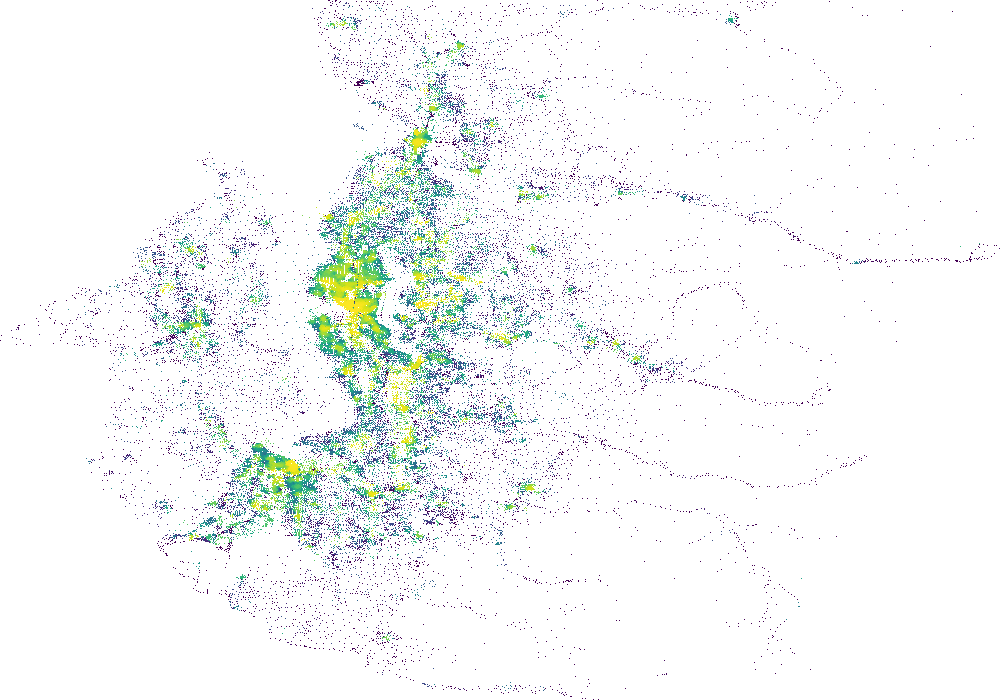

In [38]:
visualize_variable('st_total_jobs_sum_800_flat')

In [39]:
# Set explanatory variables
expl_vars = [
    'st_ln_zones_total_jobs_15_minutes_am_single_vehicle_to_work_travel_time',
    'st_ln_block_groups_mean_res_rent',
    'st_is_transit_stop_sum_1600_flat',
    'st_sum_income_ave_1600_flat', 
    'st_block_groups_prop_year_built_2022', 
    'st_block_groups_prop_children_0',
    'st_ln_block_groups_density_housing_units'
]

Disaggregating prop_children_0 to blocks from block_groups
Disaggregating block_group_id to households from blocks
Calculating proportion children 0 for block_groups
Calculating number of households for block_groups
Disaggregating total_jobs_15_minutes_am_single_vehicle_to_work_travel_time to blocks from zones
Calculating number of jobs for zones
Disaggregating zone_id to jobs from blocks
Calculating sum_income of households for blocks
Disaggregating mean_res_rent to blocks from block_groups
Calculating mean_res_rent of blocks for block_groups
Disaggregating density_housing_units to blocks from block_groups
Calculating density of housing_units for block_groups
Calculating number of housing_units for block_groups
Disaggregating block_group_id to housing_units from blocks
Calculating sum_acres of blocks for block_groups
Disaggregating prop_year_built_2022 to blocks from block_groups
Calculating proportion year_built 2022 for block_groups


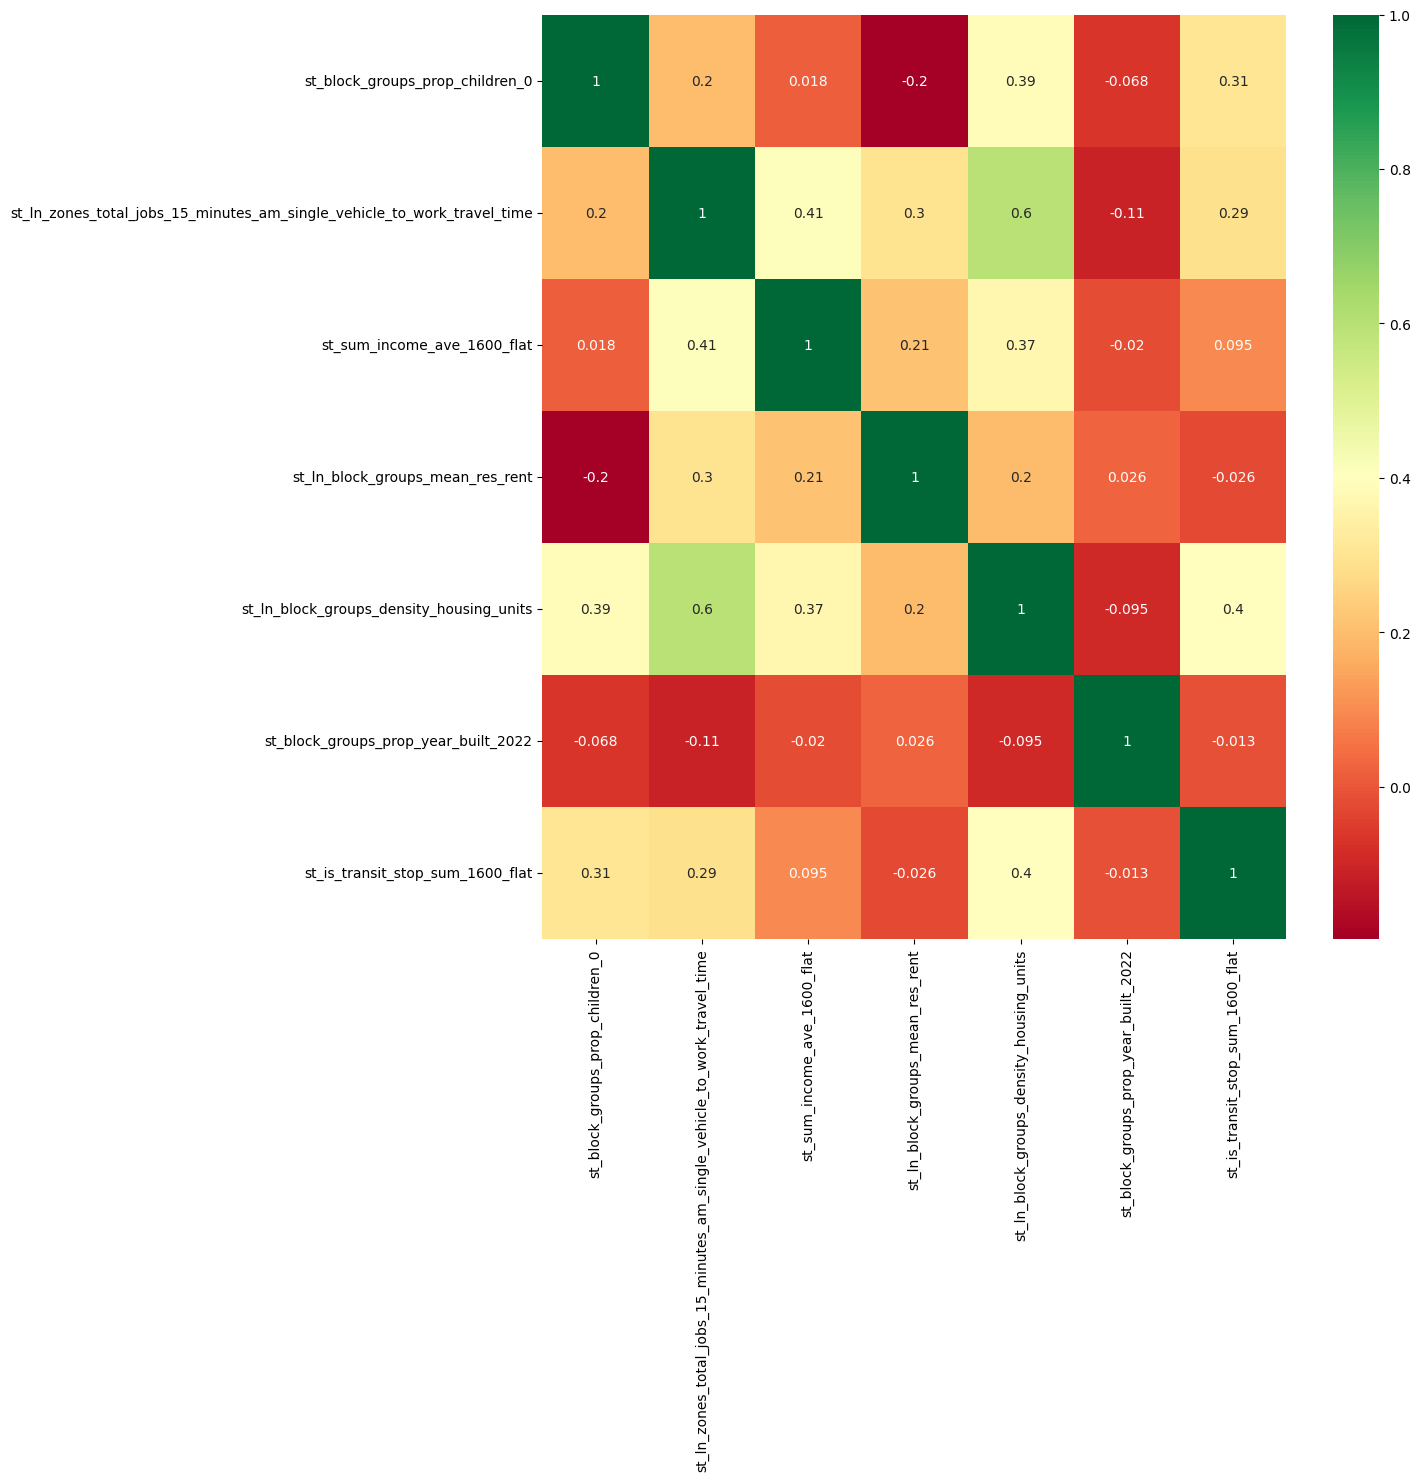

In [40]:
corr_plot(expl_vars)

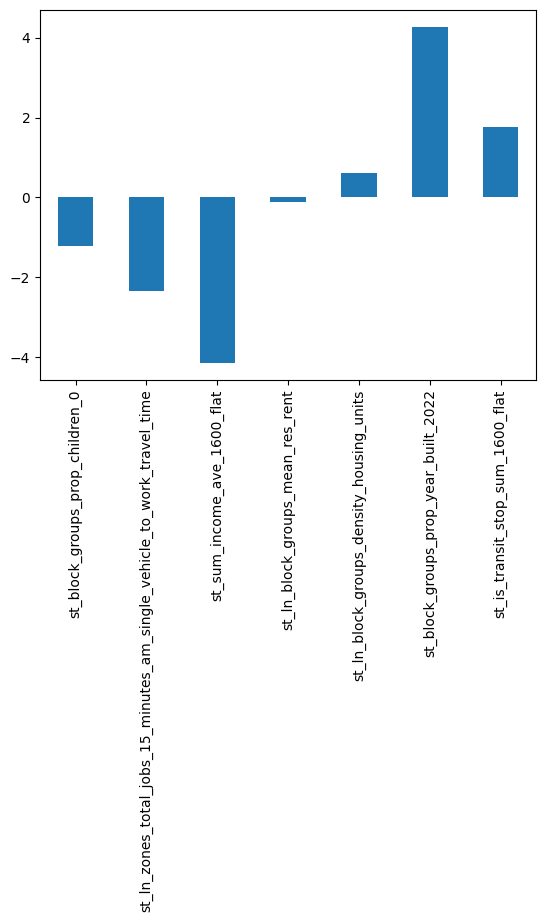

In [41]:
skew_plot(expl_vars)

In [42]:
# hlcm1: high income
m = LargeMultinomialLogitStep()
m.choosers = ['households']
m.chooser_sample_size = 5000
m.chooser_filters = '(recent_mover == 1) & (income_quartile == 4)'
m.alternatives = ['blocks']
m.choice_column = 'block_id'
m.constrained_choices = True
m.alt_sample_size = 100 
m.out_chooser_filters = '(block_id == "-1") & (income_quartile == 4)'
m.alt_capacity = 'vacant_housing_units'
m.out_alt_filters = 'vacant_housing_units > 0'

m.model_expression = util.str_model_expression(expl_vars, add_constant=False)
m.fit()
m.name = 'hlcm1'

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          5,000
Model:         Multinomial Logit   Df Residuals:              4,993
Method:       Maximum Likelihood   Df Model:                      7
Date:                 2026-09-16   Pseudo R-squ.:             0.108
Time:                      12:55   Pseudo R-bar-squ.:         0.108
AIC:                  41,101.066   Log-Likelihood:      -20,543.533
BIC:                  41,146.686   LL-Null:             -23,025.851
                                                                             coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------
st_ln_zones_total_jobs_15_minutes_am_single_vehicle_to_work_travel_time   -0.0849     0.031    -2.701     0.007             
st_ln_block_groups_mean_res_rent                                           0.1379

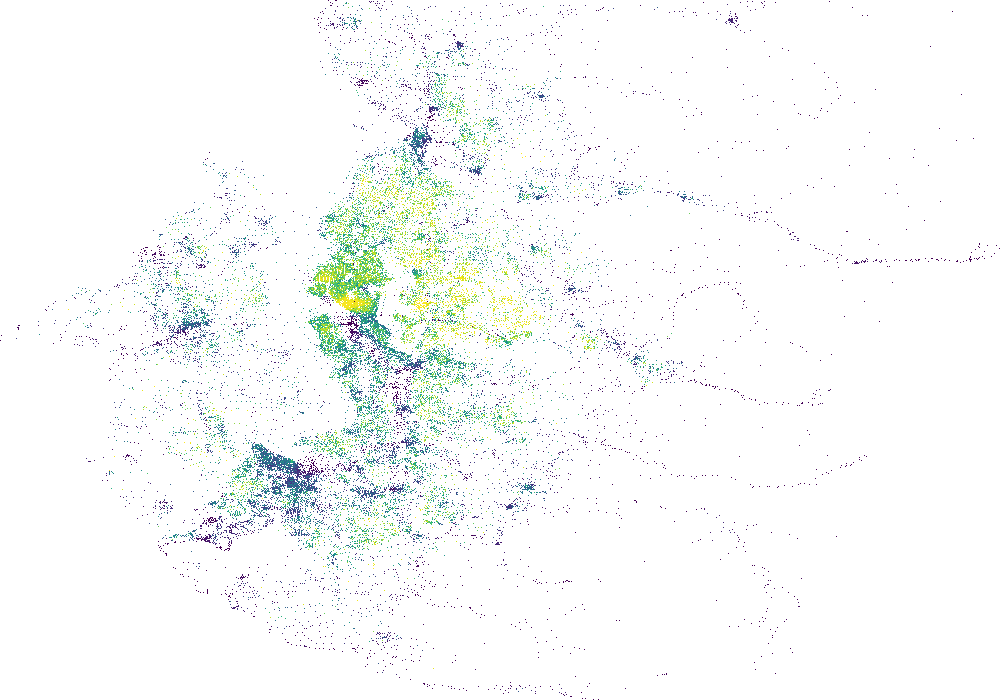

In [43]:
proba = create_probs_table(m, sample_choosers= 1, idx='block_id')
plot_probas(proba)

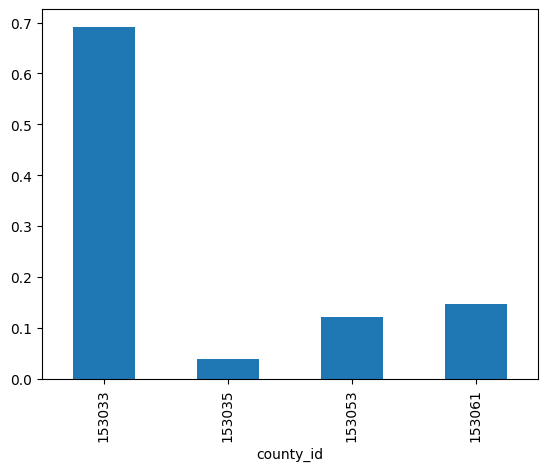

In [44]:
summed_probas('county_id', proba)

In [45]:
# register model (will overwrite previous model)
mm.register(m)

Saving 'hlcm1.yaml': c:\Users\jkolberg\PythonProjects\PSRC\psrc_mazsim\projects\baseline2023\configs\submodels
Registering model step 'hlcm1'


In [46]:
# hlcm2: mid-high income
m = LargeMultinomialLogitStep()
m.choosers = ['households']
m.chooser_sample_size = 5000
m.chooser_filters = '(recent_mover == 1) & (income_quartile == 3)'
m.alternatives = ['blocks']
m.choice_column = 'block_id'
m.constrained_choices = True
m.alt_sample_size = 100 
m.out_chooser_filters = '(block_id == "-1") & (income_quartile == 3)'
m.alt_capacity = 'vacant_housing_units'
m.out_alt_filters = 'vacant_housing_units > 0'

m.model_expression = util.str_model_expression(expl_vars, add_constant=False)
m.fit()
m.name = 'hlcm2'

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          5,000
Model:         Multinomial Logit   Df Residuals:              4,993
Method:       Maximum Likelihood   Df Model:                      7
Date:                 2026-09-16   Pseudo R-squ.:             0.076
Time:                      12:55   Pseudo R-bar-squ.:         0.076
AIC:                  42,550.431   Log-Likelihood:      -21,268.215
BIC:                  42,596.051   LL-Null:             -23,025.851
                                                                             coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------
st_ln_zones_total_jobs_15_minutes_am_single_vehicle_to_work_travel_time   -0.2214     0.027    -8.125     0.000             
st_ln_block_groups_mean_res_rent                                          -0.1164

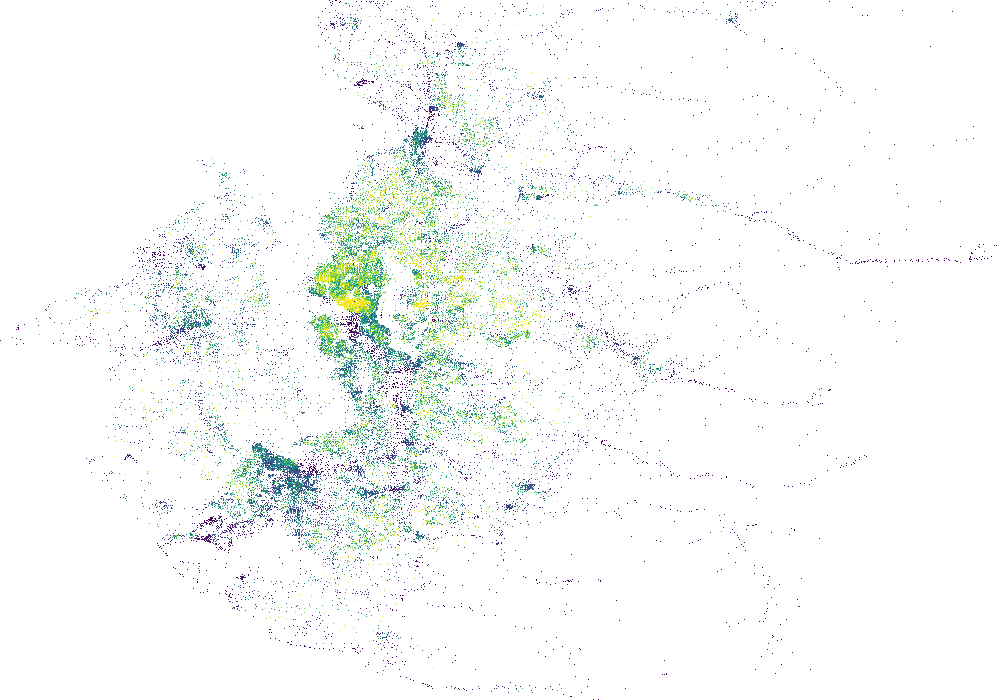

In [47]:
proba = create_probs_table(m, sample_choosers= 1, idx='block_id')
plot_probas(proba)

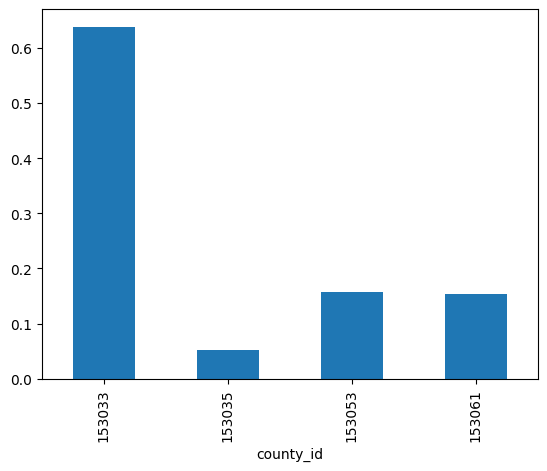

In [48]:
summed_probas('county_id', proba)

In [49]:
# register model (will overwrite previous model)
mm.register(m)

Saving 'hlcm2.yaml': c:\Users\jkolberg\PythonProjects\PSRC\psrc_mazsim\projects\baseline2023\configs\submodels
Registering model step 'hlcm2'


In [50]:
# hlcm3: mid-low income
m = LargeMultinomialLogitStep()
m.choosers = ['households']
m.chooser_sample_size = 5000
m.chooser_filters = '(recent_mover == 1) & (income_quartile == 2)'
m.alternatives = ['blocks']
m.choice_column = 'block_id'
m.constrained_choices = True
m.alt_sample_size = 100 
m.out_chooser_filters = '(block_id == "-1") & (income_quartile == 2)'
m.alt_capacity = 'vacant_housing_units'
m.out_alt_filters = 'vacant_housing_units > 0'

m.model_expression = util.str_model_expression(expl_vars, add_constant=False)
m.fit()
m.name = 'hlcm3'

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          5,000
Model:         Multinomial Logit   Df Residuals:              4,993
Method:       Maximum Likelihood   Df Model:                      7
Date:                 2026-09-16   Pseudo R-squ.:             0.068
Time:                      12:55   Pseudo R-bar-squ.:         0.068
AIC:                  42,929.251   Log-Likelihood:      -21,457.625
BIC:                  42,974.871   LL-Null:             -23,025.851
                                                                             coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------
st_ln_zones_total_jobs_15_minutes_am_single_vehicle_to_work_travel_time   -0.0006     0.034    -0.019     0.985             
st_ln_block_groups_mean_res_rent                                          -0.3082

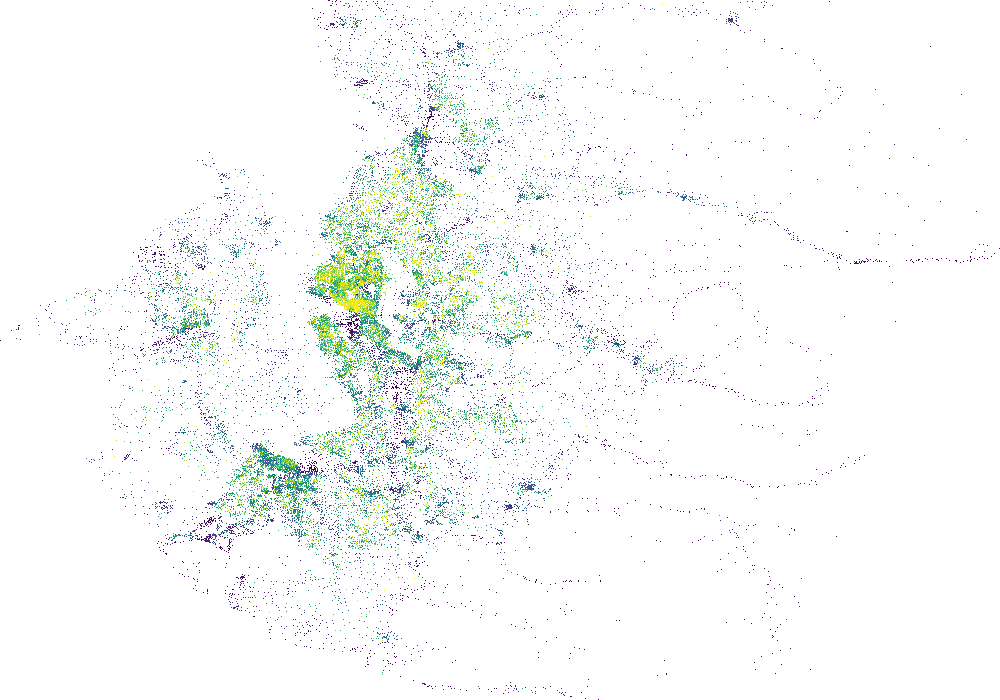

In [51]:
proba = create_probs_table(m, sample_choosers= 1, idx='block_id')
plot_probas(proba)

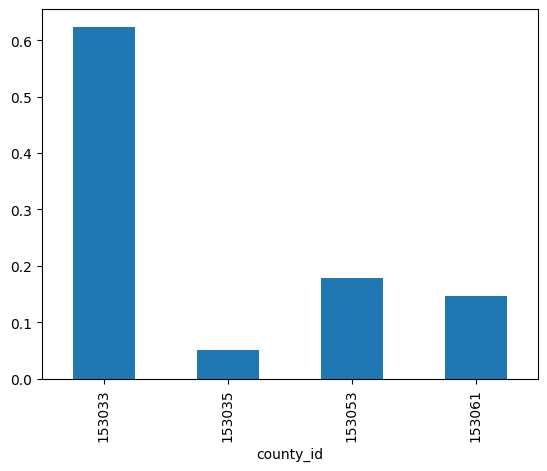

In [52]:
summed_probas('county_id', proba)

In [53]:
# register model (will overwrite previous model)
mm.register(m)

Saving 'hlcm3.yaml': c:\Users\jkolberg\PythonProjects\PSRC\psrc_mazsim\projects\baseline2023\configs\submodels
Registering model step 'hlcm3'


In [54]:
# hlcm4: low income
m = LargeMultinomialLogitStep()
m.choosers = ['households']
m.chooser_sample_size = 5000
m.chooser_filters = '(recent_mover == 1) & (income_quartile == 1)'
m.alternatives = ['blocks']
m.choice_column = 'block_id'
m.constrained_choices = True
m.alt_sample_size = 100 
m.out_chooser_filters = '(block_id == "-1") & (income_quartile == 1)'
m.alt_capacity = 'vacant_housing_units'
m.out_alt_filters = 'vacant_housing_units > 0'

m.model_expression = util.str_model_expression(expl_vars, add_constant=False)
m.fit()
m.name = 'hlcm4'

       -0.15269158,  0.69414837]), 20792.835525219463, {'grad': array([ 2.68092681e-06, -3.58922460e-04,  1.53928858e-05, -3.68085985e-05,
        3.93956050e-07,  1.20117602e-04, -9.33568040e-05]), 'task': 'ABNORMAL: ', 'funcalls': 54, 'nit': 16, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          5,000
Model:         Multinomial Logit   Df Residuals:              4,993
Method:       Maximum Likelihood   Df Model:                      7
Date:                 2026-09-16   Pseudo R-squ.:             0.097
Time:                      12:55   Pseudo R-bar-squ.:         0.097
AIC:                  41,599.671   Log-Likelihood:      -20,792.836
BIC:                  41,645.291   LL-Null:             -23,025.851
                                                                             coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------
st_ln_zones_total_jobs_15_minutes_am_single_vehicle_to_work_travel_time    0.0237     0.033     0.721     0.471             
st_ln_block_groups_mean_res_rent                                          -0.4644

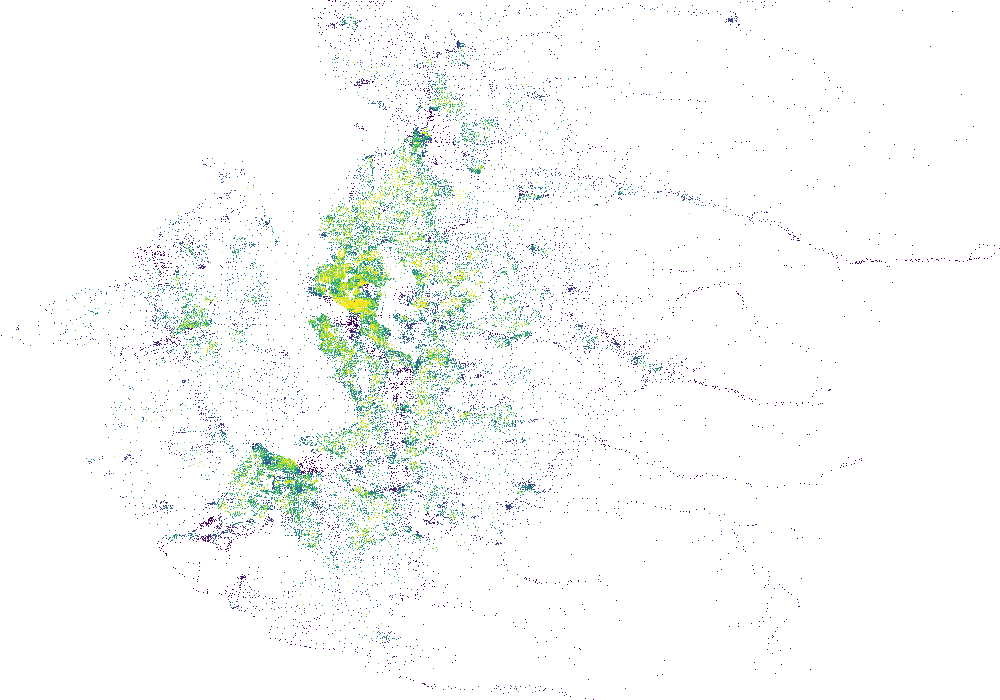

In [55]:
proba = create_probs_table(m, sample_choosers= 1, idx='block_id')
plot_probas(proba)

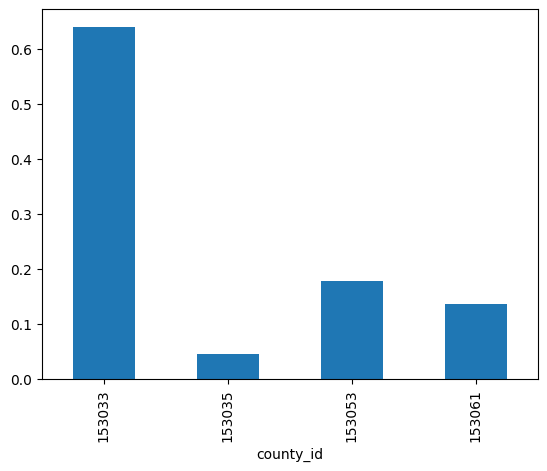

In [56]:
summed_probas('county_id', proba)

In [57]:
# register model (will overwrite previous model)
mm.register(m)

Saving 'hlcm4.yaml': c:\Users\jkolberg\PythonProjects\PSRC\psrc_mazsim\projects\baseline2023\configs\submodels
Registering model step 'hlcm4'
